In [2]:
import pandas as pd
import sqlite3

## создать подлючение к БД

In [3]:
try:
  conn = sqlite3.connect('data/checking-logs.sqlite')
  print('Подключение состоялось')
except sqlite3.Error as error:
  print('Подключение не состоялось:', error)

Подключение состоялось


## Получаем дананне из таблицы pageviews только юзеров

In [4]:
query = '''
SELECT *
FROM pageviews
WHERE uid LIKE 'user_%'
'''
pageviews = pd.io.sql.read_sql(query, conn, parse_dates=['datetime'])
pageviews

,index,uid,datetime
0,12,user_30,2020-04-17 22:46:26.785035
1,14,user_14,2020-04-18 10:53:52.623447
2,15,user_17,2020-04-18 10:56:55.833899
3,16,user_14,2020-04-18 10:57:37.331258
4,18,user_17,2020-04-18 12:05:48.200144
...,...,...,...
982,1073,user_28,2020-05-21 18:45:20.441142
983,1074,user_19,2020-05-21 23:03:06.457819
984,1075,user_25,2020-05-21 23:23:49.995349
985,1078,user_5,2020-05-22 11:30:18.368990


In [ ]:
## Получаем дананне из таблицы checker для юзеров

In [14]:
query = '''
SELECT *
FROM checker
WHERE uid LIKE 'user_%'
'''
checker = pd.io.sql.read_sql(query, conn, parse_dates=['datetime'])
checker['timestamp'] = checker['timestamp'].astype('datetime64[us]')
checker

,index,status,success,timestamp,numTrials,labname,uid
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4
...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


## считаем колличестов views

In [15]:
views = pageviews.groupby(by=pageviews['datetime'].dt.date).agg({'uid': ['count']})
views = views.reset_index()
views.columns = ['date', 'view']
views

,date,view
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


In [ ]:
## считаем колличестов commits

In [16]:
commit = checker.groupby(by=checker['timestamp'].dt.date).agg({'uid': ['count']})
commit = commit.reset_index()
commit.columns = ['date', 'commit']
commit

,date,commit
0,2020-04-17,23
1,2020-04-18,69
2,2020-04-19,33
3,2020-04-20,25
4,2020-04-21,25
5,2020-04-22,28
6,2020-04-23,43
7,2020-04-24,16
8,2020-04-25,104
9,2020-04-26,261


In [48]:
##Объединяем views и commit

In [17]:
result = views.merge(commit,on = 'date',how = 'inner')
result

,date,view,commit
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


## используя метод Pandas .plot(), создайте график
- размер шрифта должен быть 8
- размер фигуры (15,8)

<Axes: title={'center': 'Views per day'}, xlabel='date'>

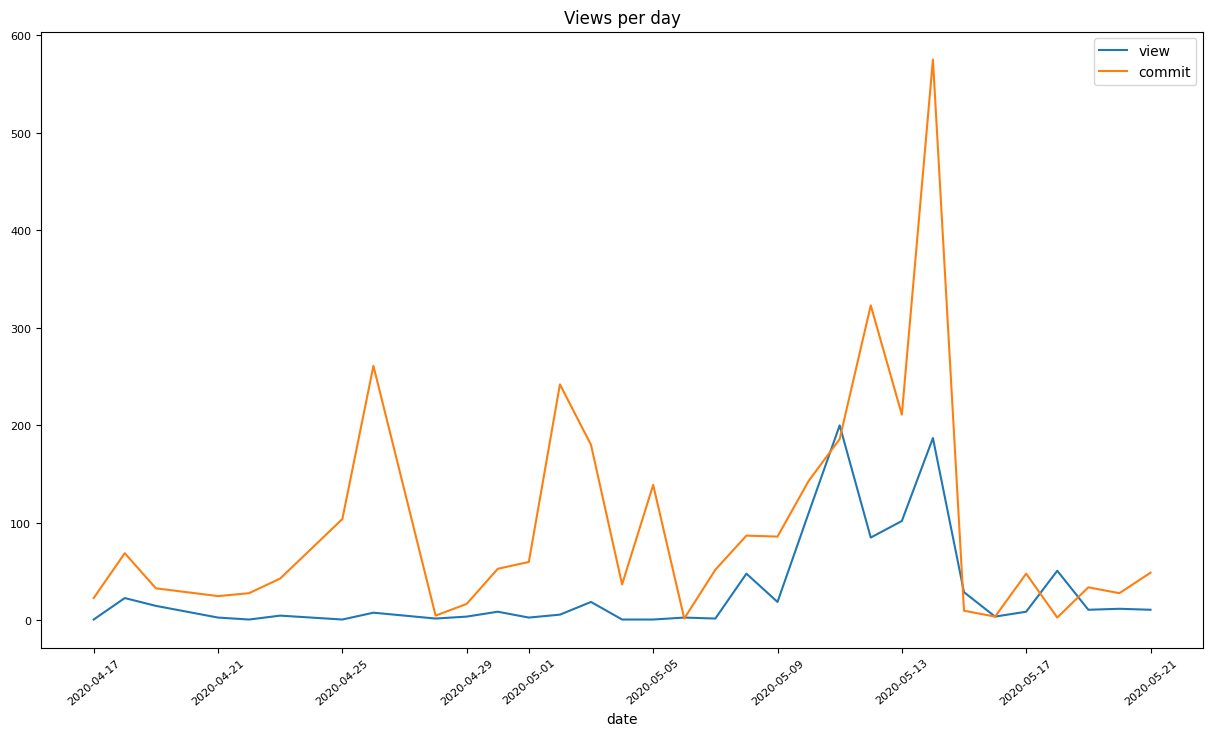

In [20]:
result.plot(x='date', y=['view','commit'], figsize=(15, 8), title='Views per day', rot=40, fontsize=8)

In [19]:
##“Сколько раз количество просмотров превышало 150?” 

In [21]:
##Ответ: 2 раза

In [22]:
conn.close()
